In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("cleaned_customer_shopping_behavior.csv")

shipping_summary = (
    df.groupby("shipping_type")
      .agg(
          customer_count=("shipping_type", "count"),
          average_spend=("purchase_amount_(usd)", "mean")
      )
      .reset_index()
)

shipping_summary


,shipping_type,customer_count,average_spend
0,2-Day Shipping,627,60.733652
1,Express,931,62.460806
2,Free Shipping,675,60.410370
3,Next Day Air,648,58.631173
4,Standard,920,60.737348
5,Store Pickup,650,59.893846


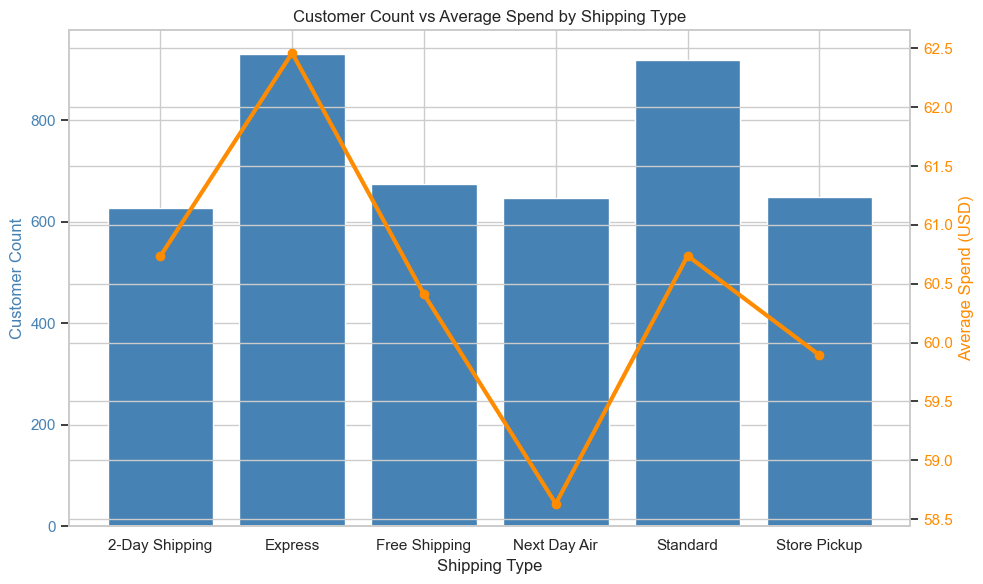

In [26]:
# --- COMBINED BAR & LINE CHART --- for Customer Count and Average Spend by Shipping Type
import matplotlib.pyplot as plt

# Create figure
fig, ax1 = plt.subplots(figsize=(10,6))

# --- BAR CHART (Customer Count) ---
bar_color = "steelblue"

ax1.bar(
    shipping_summary["shipping_type"],
    shipping_summary["customer_count"],
    color=bar_color,
    label="Customer Count"
)

ax1.set_xlabel("Shipping Type")
ax1.set_ylabel("Customer Count", color=bar_color)
ax1.tick_params(axis='y', labelcolor=bar_color)


# --- LINE CHART (Average Spend) ---
ax2 = ax1.twinx()

line_color = "darkorange"

ax2.plot(
    shipping_summary["shipping_type"],
    shipping_summary["average_spend"],
    color=line_color,
    marker="o",
    linewidth=3,
    label="Average Spend"
)

ax2.set_ylabel("Average Spend (USD)", color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)


# --- TITLE & LAYOUT ---
plt.title("Customer Count vs Average Spend by Shipping Type")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

ValueError: ['green'] is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

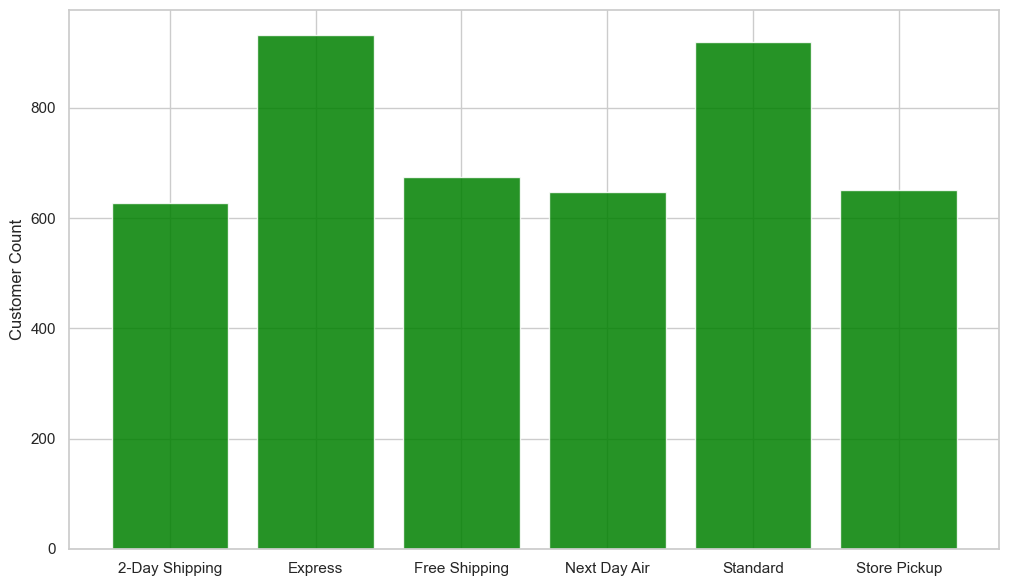

In [ ]:
#More edits to the above code to make it more visually appealing and easier to understand.

import matplotlib.pyplot as plt
import seaborn as sns

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12,7))

# Colors
bar_color = "#4E79A7"      # professional blue
line_color = "#F28E2B"     # professional orange

# --- BAR CHART ---
bars = ax1.bar(
    shipping_summary["shipping_type"],
    shipping_summary["customer_count"],
    color= ['green'],
    alpha=0.85,
    label="Customer Count"
)

ax1.set_ylabel("Customer Count", fontsize=12, color='green')
ax1.tick_params(axis='y', labelcolor=['green'], labelsize=11)

# Gridlines (only horizontal)
ax1.grid(axis="y", linestyle="--", alpha=0.6)
ax1.grid(axis="x", visible=False)


# --- LINE CHART ---
ax2 = ax1.twinx()

line = ax2.plot(
    shipping_summary["shipping_type"],
    shipping_summary["average_spend"],
    color=line_color,
    marker="o",
    markersize=8,
    linewidth=3,
    label="Average Spend"
)

ax2.set_ylabel("Average Spend (USD)", fontsize=12, color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)


# --- TITLE ---
plt.title(
    "Comparison of Customer Count and Average Spend by Shipping Type",
    fontsize=16,
    weight="bold",
    pad=15
)

# Improve x-label readability
plt.xticks(rotation=30, fontsize=11)

# Combine legends
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

ax1.legend(lines, labels, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()